<a href="https://colab.research.google.com/github/Sujatha-Nethmini/ML_CW/blob/main/machineLearning_CW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML_CW/WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [4]:
# Basic info
print("\n--- INFO ---")
df.info()

print("\n--- Describe (numeric) ---")
df.describe()



--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Missing values
print("\n--- Missing values ---")
print(df.isna().sum())



--- Missing values ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
# Unique values in object columns
obj_cols = df.select_dtypes(include='object').columns
for c in obj_cols:
    print(f"\n{c}: {df[c].unique()[:10]} ...")



customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU'] ...

gender: ['Female' 'Male'] ...

Partner: ['Yes' 'No'] ...

Dependents: ['No' 'Yes'] ...

PhoneService: ['No' 'Yes'] ...

MultipleLines: ['No phone service' 'No' 'Yes'] ...

InternetService: ['DSL' 'Fiber optic' 'No'] ...

OnlineSecurity: ['No' 'Yes' 'No internet service'] ...

OnlineBackup: ['Yes' 'No' 'No internet service'] ...

DeviceProtection: ['No' 'Yes' 'No internet service'] ...

TechSupport: ['No' 'Yes' 'No internet service'] ...

StreamingTV: ['No' 'Yes' 'No internet service'] ...

StreamingMovies: ['No' 'Yes' 'No internet service'] ...

Contract: ['Month-to-month' 'One year' 'Two year'] ...

PaperlessBilling: ['Yes' 'No'] ...

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] ...

TotalCharges: ['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05

In [7]:
# Target distribution
df['Churn'].value_counts(), df['Churn'].value_counts(normalize=True)*100


(Churn
 No     5174
 Yes    1869
 Name: count, dtype: int64,
 Churn
 No     73.463013
 Yes    26.536987
 Name: proportion, dtype: float64)

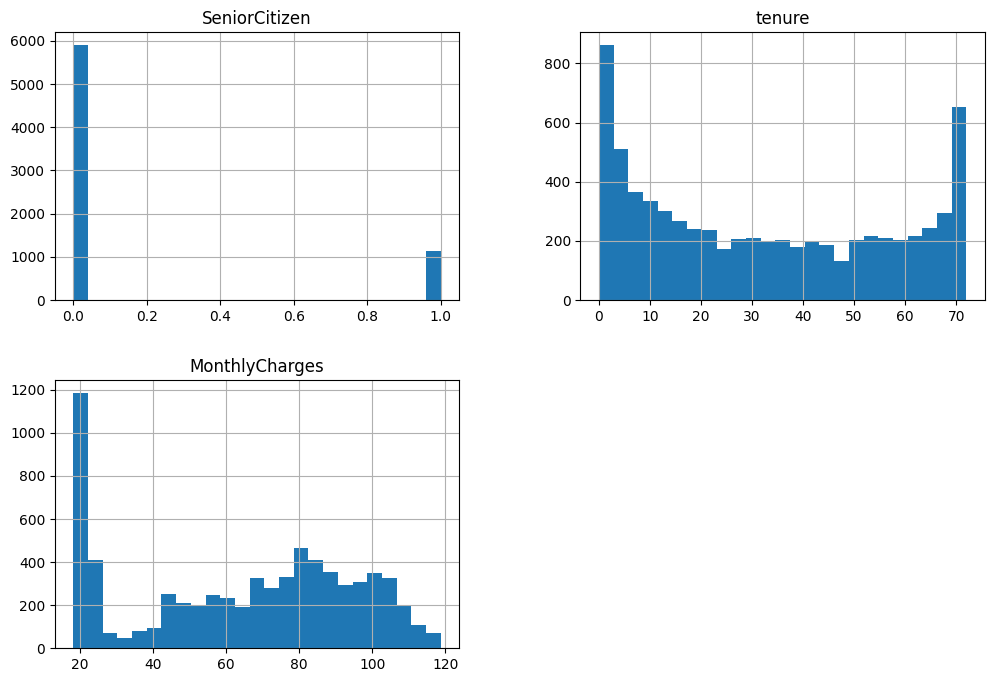

In [8]:
# Histograms
df.select_dtypes(include=np.number).hist(bins=25, figsize=(12,8))
plt.show()


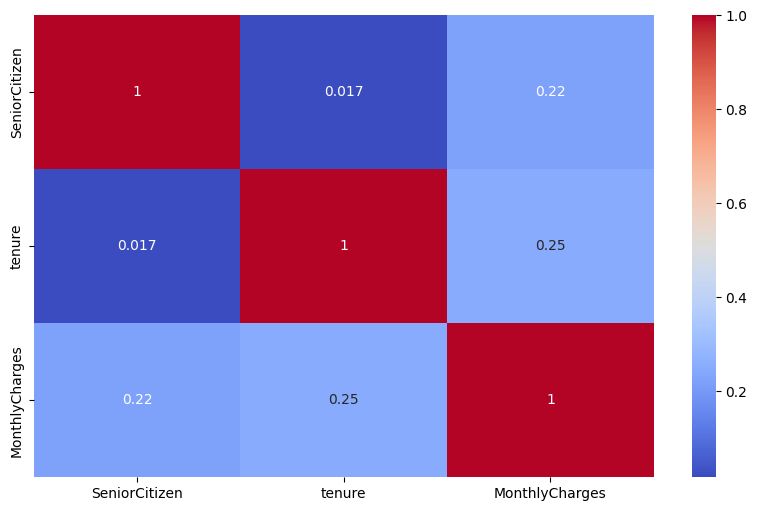

In [9]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.show()


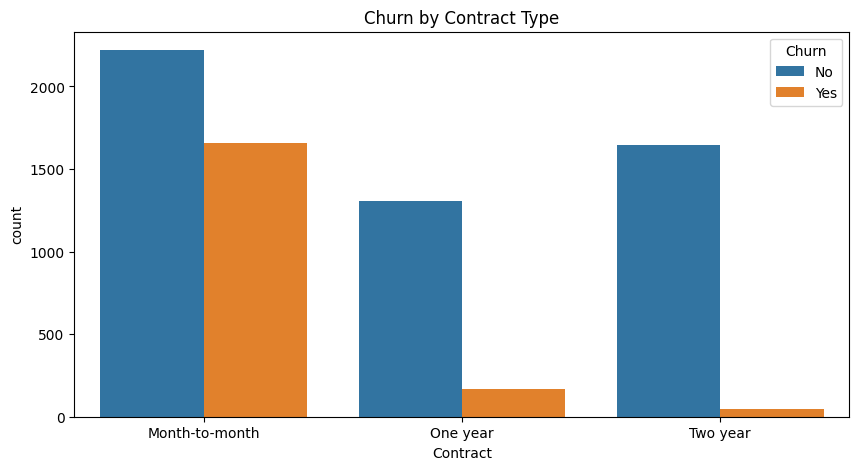

In [10]:
# Churn by Contract type
plt.figure(figsize=(10,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()


In [11]:
# Check TotalCharges dtype issue
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("Blank TotalCharges rows:", (df['TotalCharges']==" ").sum())
df[df['TotalCharges']==" "].head()


TotalCharges dtype: object
Blank TotalCharges rows: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


In [12]:
(df['TotalCharges'].str.strip() == "").sum()


np.int64(11)

In [14]:
# Make a fresh copy
data = df.copy()

In [15]:
# 1. Fix TotalCharges: convert to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [16]:
# Check how many became NaN
print("NaNs in TotalCharges:", data['TotalCharges'].isna().sum())

NaNs in TotalCharges: 11


In [17]:
# Drop rows with NaN in TotalCharges (usually around 11 rows)
data = data.dropna(subset=['TotalCharges'])

In [18]:
# 2. Drop customerID (no predictive value)
data = data.drop(columns=['customerID'])

In [19]:
# 3. Replace "No internet service" and "No phone service" with just "No"
cols_to_fix = [
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies','MultipleLines'
]

for col in cols_to_fix:
    data[col] = data[col].replace({"No internet service": "No",
                                   "No phone service": "No"})

In [20]:
# 4. Separate features and target
X = data.drop(columns=['Churn'])
y = data['Churn'].map({'No':0, 'Yes':1})

In [21]:
# 5. Identify categorical and numeric columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [22]:
# 6. Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

In [23]:
# 7. Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((5625, 19), (1407, 19))

Accuracy: 0.728500355366027

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1033
           1       0.49      0.49      0.49       374

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407


Confusion Matrix:
[[840 193]
 [189 185]]

ROC-AUC: 0.6534197679775949


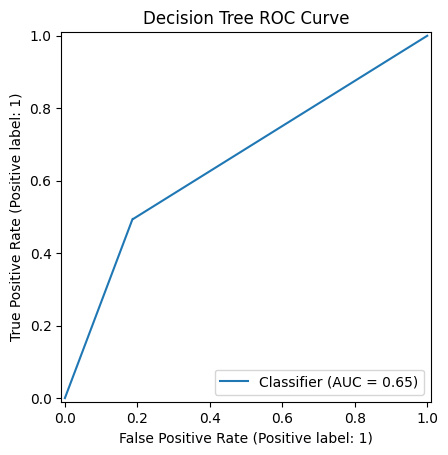

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.pipeline import Pipeline

# Build a pipeline: preprocessor -> decision tree
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# Fit the model
dt_model.fit(X_train, y_train)

# Predictions
y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC-AUC
print("\nROC-AUC:", roc_auc_score(y_test, y_proba))

# Plot ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Decision Tree ROC Curve")
plt.show()


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'dt__max_depth': [3, 5, 7, 10, None],
    'dt__min_samples_split': [2, 10, 20],
    'dt__min_samples_leaf': [1, 5, 10],
    'dt__criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    scoring='f1',        # IMPORTANT since dataset is imbalanced
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print("\nBest Params:", grid_dt.best_params_)
print("\nBest F1 Score:", grid_dt.best_score_)


Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Params: {'dt__criterion': 'entropy', 'dt__max_depth': 5, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}

Best F1 Score: 0.5937041341032605


Accuracy: 0.7882018479033405

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1033
           1       0.60      0.63      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.74      0.73      1407
weighted avg       0.79      0.79      0.79      1407


Confusion Matrix:
[[875 158]
 [140 234]]

ROC-AUC: 0.8240444994331448


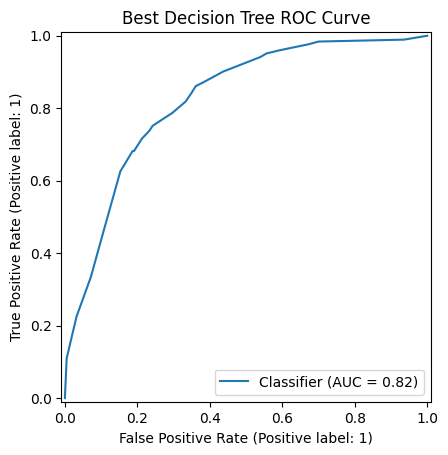

In [26]:
best_dt = grid_dt.best_estimator_

y_pred_best = best_dt.predict(X_test)
y_proba_best = best_dt.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nROC-AUC:", roc_auc_score(y_test, y_proba_best))

RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.title("Best Decision Tree ROC Curve")
plt.show()
